# 第2章 Vision and Language

# 2.3 LLaVA

## 2.3.4 ダウンストリームタスクに向けた LVLM のファインチューニング

このノートブックは、本書の 2.3.4 項に対応しています。  

このノートブックでは、日本語対応の LLaVA 系モデル
[Onely7/llava-1.5-llm-jp-3.1-1.8b-instruct4](https://huggingface.co/Onely7/llava-1.5-llm-jp-3.1-1.8b-instruct4)
を、[Oxford-IIIT Pet](https://www.robots.ox.ac.uk/~vgg/data/pets/) から選んだ犬・猫 6 品種の分類タスクに QLoRA で適応します。

本書では、学習済みのモデルが持つ知識や表現を利用して取り組む具体的な目的タスクを **ダウンストリームタスク** と呼びます。  
ここでは、入力画像から候補の品種を 1 つ選び、**品種名だけを出力する**ように学習します。

学習データは、**入力画像、ユーザー側の指示文、アシスタント側の正解応答文**からなる指示追従形式にします。  
画像と指示文は応答生成の条件とし、正解応答と応答の終了を示すトークンを損失計算の対象にします。

GPU メモリを抑えるため、ベースモデルの重みを 4 ビットで保持しながら LoRA の追加パラメータを学習する QLoRA を使用します。  
今回は、視覚エンコーダと LLaVA のアダプタを固定し、LLM 側の主要な線形層に LoRA を追加します。  
学習後は、LoRA で学習した差分を BF16 のベースモデルへマージして保存します。

このノートブックでは、4 ビット量子化、LoRA の挿入先、損失計算対象、学習設定、LoRA のマージを中心に確認します。  
データ構築や可視化・評価などの補助コードは、初期状態では非表示にしています。必要に応じて表示し、確認して下さい。

### 0. Google Colab の実行環境を準備する

最初に、Google Colab のランタイムで GPU を有効にします。

次のセルで、使用するライブラリを指定したバージョンでインストールします。  
Colab に古い `torchao` が残っていると今回の PEFT と互換性の問題が生じるため、使用しない `torchao` はここでアンインストールします。

実行後は **ランタイムを一度再起動**し、このインストールセルは再実行せず、次の節から再開してください。  
必要であれば、再起動後に `%pip freeze` を実行して環境を記録できます。

In [1]:
# ========================================
# システムツールの準備
# ========================================

!apt-get update -q
!apt-get install -y tree

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  InRelease [1,578 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease [3,631 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [359 B]
Get:5 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu noble InRelease [9,161 B]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  Packages [1,870 kB]
Hit:8 http://archive.ubuntu.com/ubuntu noble InRelease
Get:9 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ Packages [73.2 kB]
Get:10 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu noble/main all Packages [10.2 MB]
Hit:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease
Hit:13 https://ppa.launchpadcontent.net/graphics-drivers/ppa/u

In [2]:
# ========================================
# 2. Pythonパッケージの準備
# ========================================

%pip install -q \
    "transformers==5.9.0" \
    "peft==0.19.1" \
    "bitsandbytes==0.50.1" \
    "accelerate==1.14.0" \
    "pillow==11.3.0"

%pip uninstall -y torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 84.0 MB/s eta 0:00:00
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [3]:
%pip freeze

absl-py==1.4.0
accelerate==1.14.0
access==1.1.10.post3
affine==3.0.1
aiofiles==25.1.0
aiohappyeyeballs==2.7.1
aiohttp==3.14.3
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.12.1
altair==5.5.0
annotated-doc==0.0.5
annotated-types==0.8.0
antlr4-python3-runtime==4.9.3
anyio==4.14.2
anywidget==0.9.21
apsw==3.53.4.0
argon2-cffi==25.1.0
argon2-cffi-bindings==26.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.2
astropy-iers-data==0.2026.8.31.0.57.9
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioop-lts==0.2.2
audioread==3.1.0
Authlib==1.8.0
autograd==1.9.1
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b7
bigframes==2.48.0
bigquery-magics==0.14.0
bitsandbytes==0.50.1
bleach==6.4.0
blinker==1.9.0
blis==1.3.3
blobfile==3.3.0
blosc2==4.12.0
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.47
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026

### 1. ライブラリを読み込み、実行環境を確認する

再起動後、必要なライブラリを読み込みます。  
ここでは、CUDA GPU が利用できることと、今回使用しない `torchao` が残っていないことを確認します。

In [4]:
import gc
import importlib.util
import itertools
import json
import random
import unicodedata
from pathlib import Path

import bitsandbytes as bnb
import torch
from IPython.display import display
from peft import (
    LoraConfig,
    PeftModel,
    get_peft_model,
    prepare_model_for_kbit_training,
)

from PIL import Image
from torch.utils.data import Dataset
from torchvision.datasets import OxfordIIITPet
from tqdm.auto import tqdm
from transformers import (
    AutoProcessor,
    BitsAndBytesConfig,
    LlavaForConditionalGeneration,
    Trainer,
    TrainingArguments,
)

# ========================================
# 実行環境を確認する
# ========================================
# 今回の実装では CUDA GPU を使用する
# Colab で GPU ランタイムを選択してから実行する
# ========================================

if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU が利用できません。GPU ランタイムを選択してください。")

# 今回は bitsandbytes による QLoRA を使用するため、torchao は使わない
# 古い torchao が残っていると PEFT の読み込み時に競合する場合がある
if importlib.util.find_spec("torchao") is not None:
    raise RuntimeError(
        "torchao が環境に残っています。"
        "Colab でアンインストールして、ランタイムを再起動してください。"
    )

### 2. 共通設定を定義する

使用するモデルと、データ、チェックポイント、LoRA の追加パラメータ、マージ済みモデル、評価結果の保存先を定義します。

In [5]:
# ========================================
# 共通設定
# ========================================

# ファインチューニングの対象とする LLaVA モデル
model_id = "Onely7/llava-1.5-llm-jp-3.1-1.8b-instruct4"

# Oxford-IIIT Pet の保存先
data_root = "./data"

# QLoRA の学習結果を保存するルートディレクトリ
output_root = Path("./llava-pet-qlora")

# 学習中のチェックポイントを保存するディレクトリ
checkpoint_dir = output_root / "checkpoints"

# 学習された LoRA adapter だけを保存するディレクトリ
adapter_dir = output_root / "adapter"

# LoRA を BF16 のベースモデルへマージしたモデルの保存先
merged_dir = output_root / "merged"

# 学習前後の評価結果を保存するディレクトリ
evaluation_dir = Path("./evaluation")

# 学習前後で共有する評価画像の保存先
shared_image_dir = evaluation_dir / "images"

### 3. ダウンストリームタスク用のデータを構築する

今回は [Oxford-IIIT Pet](https://www.robots.ox.ac.uk/~vgg/data/pets/) の 37 品種から、犬 3 品種と猫 3 品種の合計 6 品種を使用します。

- **犬**: パグ、サモエド、柴犬
- **猫**: ペルシャ、シャム、スフィンクス

画像を 1 枚入力し、6 品種の中から正しい品種を選んで、**品種名だけを出力する**タスクとして学習します。

学習には `trainval` split から各品種 25 枚、合計 150 枚を使用します。  
評価には `test` split から各品種 10 枚、合計 60 枚を使用します。

In [6]:
# ========================================
# Oxford-IIIT Pet の日本語ラベルを定義する
# ========================================
# Dataset が返す英語の品種名を、今回の日本語応答へ変換する
# ========================================

breed_name_ja = {
    "Abyssinian": "アビシニアン",
    "American Bulldog": "アメリカン・ブルドッグ",
    "American Pit Bull Terrier": "アメリカン・ピット・ブル・テリア",
    "Basset Hound": "バセット・ハウンド",
    "Beagle": "ビーグル",
    "Bengal": "ベンガル",
    "Birman": "バーマン",
    "Bombay": "ボンベイ",
    "Boxer": "ボクサー",
    "British Shorthair": "ブリティッシュ・ショートヘア",
    "Chihuahua": "チワワ",
    "Egyptian Mau": "エジプシャン・マウ",
    "English Cocker Spaniel": "イングリッシュ・コッカー・スパニエル",
    "English Setter": "イングリッシュ・セター",
    "German Shorthaired": "ジャーマン・ショートヘアード・ポインター",
    "Great Pyrenees": "グレート・ピレニーズ",
    "Havanese": "ハバニーズ",
    "Japanese Chin": "狆",
    "Keeshond": "キースホンド",
    "Leonberger": "レオンベルガー",
    "Maine Coon": "メイン・クーン",
    "Miniature Pinscher": "ミニチュア・ピンシャー",
    "Newfoundland": "ニューファンドランド",
    "Persian": "ペルシャ",
    "Pomeranian": "ポメラニアン",
    "Pug": "パグ",
    "Ragdoll": "ラグドール",
    "Russian Blue": "ロシアンブルー",
    "Saint Bernard": "セント・バーナード",
    "Samoyed": "サモエド",
    "Scottish Terrier": "スコティッシュ・テリア",
    "Shiba Inu": "柴犬",
    "Siamese": "シャム",
    "Sphynx": "スフィンクス",
    "Staffordshire Bull Terrier": "スタッフォードシャー・ブル・テリア",
    "Wheaten Terrier": "ウィートン・テリア",
    "Yorkshire Terrier": "ヨークシャー・テリア",
}


# ========================================
# 今回のダウンストリームタスクで使用する6品種を定義する
# ========================================
# 犬3品種、猫3品種から、見た目の差が比較的大きそうな候補を選ぶ
# ========================================

selected_breeds = [
    "Pug",
    "Samoyed",
    "Shiba Inu",
    "Persian",
    "Siamese",
    "Sphynx",
]

In [7]:
# ========================================
# Oxford-IIIT Pet のデータセットを構築する
# ========================================

class PetBreedDataset(Dataset):
    """指定した品種だけを抽出し、LLaVA 用のサンプルを返す"""

    def __init__(
        self,
        root,
        split,
        selected_breeds,
        samples_per_class=None,
        seed=42,
    ):
        # category を指定すると、37品種のクラス ID が target として返る
        self.dataset = OxfordIIITPet(
            root=root,
            split=split,
            target_types="category",
            download=True,
        )

        # 元データセットの37品種すべての英語名を保持する
        self.all_labels_en = list(self.dataset.classes)

        # 同じ品種を二重に指定していないことを確認する
        if len(selected_breeds) != len(set(selected_breeds)):
            raise ValueError("selected_breeds に重複した品種名が含まれています。")

        # 指定した品種が Oxford-IIIT Pet に存在することを確認する
        unknown_breeds = [
            breed
            for breed in selected_breeds
            if breed not in self.all_labels_en
        ]
        if unknown_breeds:
            raise ValueError(
                f"Oxford-IIIT Pet に存在しない品種があります: {unknown_breeds}"
            )

        # 各品種に日本語名が定義されていることを確認する
        missing_labels = [
            breed for breed in selected_breeds if breed not in breed_name_ja
        ]
        if missing_labels:
            raise ValueError(
                f"日本語名が定義されていない品種があります: {missing_labels}"
            )

        # 今回使用する英語名と日本語名を、指定された順序で保持する
        self.labels_en = list(selected_breeds)
        self.labels_ja = [breed_name_ja[breed] for breed in self.labels_en]

        # 元の37クラスにおける対象品種のクラス ID を取得する
        selected_class_ids = {
            self.dataset.class_to_idx[breed] for breed in self.labels_en
        }

        # プロンプトには今回使用する品種だけを候補として表示する
        candidates = "、".join(self.labels_ja)
        self.question = (
            "この画像の犬または猫の品種を、次の候補から1つ選んでください。\n"
            f"候補: {candidates}\n"
            "品種名だけを出力してください。"
        )

        # 各対象クラスに属するサンプルのインデックスを集める
        class_indices = {
            class_id: [] for class_id in selected_class_ids
        }

        # Dataset の公開 API からラベルを得る
        for index in range(len(self.dataset)):
            image, label_id = self.dataset[index]
            label_id = int(label_id)

            if label_id in selected_class_ids:
                class_indices[label_id].append(index)

            # ラベルだけを使い、画像は不要なのでここで閉じる
            image.close()

        # 同じ seed なら同じサンプルが選ばれるようにする
        rng = random.Random(seed)
        selected_indices = []

        # selected_breeds に指定した順番で各クラスから抽出する
        for breed in self.labels_en:
            class_id = self.dataset.class_to_idx[breed]
            indices = class_indices[class_id]

            if samples_per_class is None:
                # None の場合は、その品種の全サンプルを使用する
                selected = list(indices)
            else:
                if len(indices) < samples_per_class:
                    raise ValueError(f"{breed} のサンプル数が不足しています。")

                # 指定枚数だけを重複なしでランダムに抽出する
                selected = rng.sample(indices, samples_per_class)

            selected_indices.extend(selected)

        # クラスごとに連続しないよう、最後に全サンプルを混ぜる
        rng.shuffle(selected_indices)
        self.indices = selected_indices

    def __len__(self):
        """今回使用するサンプル数を返す"""
        return len(self.indices)

    def __getitem__(self, index):
        """画像、質問文、日本語の正解応答を1サンプル分返す"""
        dataset_index = self.indices[index]
        image, label_id = self.dataset[dataset_index]
        label_id = int(label_id)

        # label_id は37クラス全体に対する ID として解釈する
        label_en = self.all_labels_en[label_id]
        label_ja = breed_name_ja[label_en]

        return {
            "image": image,
            "question": self.question,
            "answer": label_ja,
        }

学習データと評価データを作成します。  
乱数 seed を固定し、同じ条件で実行したときに同じサンプルが選ばれるようにします。

100%|██████████| 792M/792M [00:45<00:00, 17.5MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 9.31MB/s]


学習サンプル数: 150
評価サンプル数: 60
クラス数: 6
対象クラス: パグ、サモエド、柴犬、ペルシャ、シャム、スフィンクス

=== 入力画像 ===


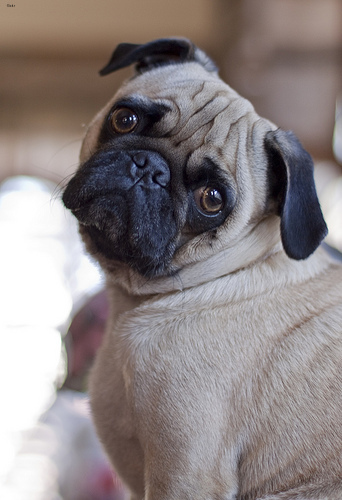


=== 質問文 ===
この画像の犬または猫の品種を、次の候補から1つ選んでください。
候補: パグ、サモエド、柴犬、ペルシャ、シャム、スフィンクス
品種名だけを出力してください。

=== 正解応答 ===
パグ


In [8]:
# ========================================
# 学習データと評価データを作成する
# ========================================
# trainval と test は Oxford-IIIT Pet が提供する別 split を使う
# ========================================

# trainval split から各品種25枚ずつ抽出する
train_dataset = PetBreedDataset(
    root=data_root,
    split="trainval",
    selected_breeds=selected_breeds,
    samples_per_class=25,
    seed=42,
)

# test split から各品種10枚ずつ抽出する
eval_dataset = PetBreedDataset(
    root=data_root,
    split="test",
    selected_breeds=selected_breeds,
    samples_per_class=10,
    seed=42,
)

print(f"学習サンプル数: {len(train_dataset)}")
print(f"評価サンプル数: {len(eval_dataset)}")
print(f"クラス数: {len(train_dataset.labels_ja)}")
print("対象クラス: " + "、".join(train_dataset.labels_ja))

# 学習データの例を1件確認する
sample = train_dataset[0]

print()
print("=== 入力画像 ===")
display(sample["image"])

print()
print("=== 質問文 ===")
print(sample["question"])

print()
print("=== 正解応答 ===")
print(sample["answer"])

sample["image"].close()

### 4. Processor を読み込む

LLaVA では、画像とテキストをまとめてモデル入力へ変換します。  
`Processor` は、画像の前処理、チャットテンプレートの適用、テキストのトークン化などをまとめて扱います。

このモデルの Tokenizer はデフォルトで right padding を使用します。  
後で系列の先頭からプロンプト部分（アシスタント応答開始位置まで）を損失計算の対象から除外するため、この実装でも right padding を明示的に設定します。

In [9]:
# ========================================
# Processor を読み込む
# ========================================

processor = AutoProcessor.from_pretrained(
    model_id,
    backend="torchvision",
)

# 後続の損失マスク処理では right padding を前提とする
processor.tokenizer.padding_side = "right"

# pad token がない場合は、EOS token を padding に使用する
if processor.tokenizer.pad_token_id is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

processor_config.json:   0%|          | 0.00/713 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.24k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/581 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/6.41M [00:00<?, ?B/s]

### 5. QLoRA 用にモデル本体を 4 ビットで読み込む

GPU メモリが限られている場合には QLoRA が選択肢になります。  
QLoRA は、モデル本体の重みを 4 ビットで保持しながら、LoRA の追加パラメータを学習する方法です。

ここでは、4-bit NormalFloat（NF4）量子化、double quantization、BF16 の計算用データ型を使用します。  
モデル本体の重みは 4 ビットで保持されますが、行列積などの計算時には BF16 などの計算用データ型へ逆量子化して使用されます。

今回は LLM 側を LoRA で調整するため、視覚エンコーダ、LVLM のアダプタ、LM ヘッドは 4 ビット変換の対象から外します。

### 5. QLoRA 用にモデル本体を 4 ビットで読み込む

GPU メモリを抑えて追加学習するため、今回は QLoRA を使用します。  
QLoRA では、量子化対象の線形層の重みを 4 ビットで保持しながら、LoRA の追加パラメータを学習します。

ここでは、4-bit NormalFloat（NF4）、double quantization、BF16 の計算用データ型を使用します。  
4 ビットで保持された重みは、行列積などの計算時には BF16 の計算用データ型へ逆量子化して使用されます。

この実装では、視覚エンコーダ、LVLM のアダプタ、LM ヘッドは量子化せず BF16 のまま保持します。  
LoRA は次節で LLM 側の主要な線形層に追加します。

In [10]:
# ========================================
# 4-bit 量子化設定を作成する
# ========================================

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,  # 対象となる Linear 層の重みを 4-bit で保持する
    bnb_4bit_quant_type="nf4",  # NF4 量子化を使用する
    bnb_4bit_use_double_quant=True,  # 量子化定数もさらに量子化する
    bnb_4bit_compute_dtype=torch.bfloat16,  # 4-bit 層の計算には BF16 を使用する
    # 視覚エンコーダ、LVLM のアダプタ、LM ヘッド は 4-bit 量子化せず BF16 のまま保持する
    llm_int8_skip_modules=[
        "model.vision_tower",
        "model.multi_modal_projector",
        "lm_head",
    ],
)

# ========================================
# 学習用の 4-bit LLaVA モデルを読み込む
# ========================================

model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    dtype=torch.bfloat16,  # dtype は量子化されない浮動小数点モジュールなどに適用される
    device_map=0,  # Colab の単一 GPU 上で学習するため、GPU 0 にモデルを配置する
)

# 学習では KV cache を使用しない
model.config.use_cache = False

model.safetensors: reconstructing file:   0%|          |  0.00B / 4.35GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/614 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/131 [00:00<?, ?B/s]

In [11]:
# @title
# ========================================
# 4-bit 量子化の適用範囲を確認する
# ========================================
# LLM 側の線形層は Linear4bit に変換され、
# 視覚エンコーダ、LVLM のアダプタ、LM ヘッドは
# 4-bit 量子化されていないことを確認する
# ========================================

module_groups = [
    "model.language_model",
    "model.vision_tower",
    "model.multi_modal_projector",
    "lm_head",
]

for module_name in module_groups:
    # 指定したモジュール自身と、その配下にある Linear4bit 層を数える
    count = sum(
        isinstance(module, bnb.nn.Linear4bit)
        for name, module in model.named_modules()
        if name == module_name or name.startswith(f"{module_name}.")
    )
    print(f"{module_name}: Linear4bit 層 = {count}")

model.language_model: Linear4bit 層 = 168
model.vision_tower: Linear4bit 層 = 0
model.multi_modal_projector: Linear4bit 層 = 0
lm_head: Linear4bit 層 = 0


量子化したモデルを、PEFT による追加学習に向けて準備します。  
今回は速度を優先し、勾配チェックポインティングは使用しません。

In [12]:
# ========================================
# 4-bit モデルを PEFT 学習用に準備する
# ========================================
# ベースモデルを固定し、量子化モデルを PEFT 学習向けに準備する
# LoRA の追加パラメータは次節で挿入する
# ========================================

model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=False,
)

### 6. LLM 側に LoRA を入れる

LVLM で LoRA を使う場合、まずは LLM 側の線形層に LoRA を入れ、視覚エンコーダを固定する設定から検討できます。  
この実装では、LLM のアテンション機構とフィードフォワード層に含まれる主要な線形層を対象にします。

具体的には、`language_model` 配下の `q_proj`、`k_proj`、`v_proj`、`o_proj`、`gate_proj`、`up_proj`、`down_proj` に LoRA を追加します。
視覚エンコーダ `vision_tower`、LVLM のアダプタ `multi_modal_projector`、LM ヘッド `lm_head` は学習対象にしません。

In [13]:
# ========================================
# LLM 側で LoRA の対象とする層を選択する
# ========================================
# アテンション機構とフィードフォワード層の主要な線形層を対象とする
# 視覚エンコーダとアダプタと LM ヘッドには LoRA を入れない
# ========================================

lora_layer_names = {
    "q_proj",
    "k_proj",
    "v_proj",
    "o_proj",
    "gate_proj",
    "up_proj",
    "down_proj",
}

target_modules = []

for name, _ in model.named_modules():
    # モジュール名の最後の部分を取り出す
    last_name = name.rsplit(".", 1)[-1]

    # LLM 配下で、指定した名前の層だけを対象にする
    if (
        name.startswith("model.language_model.")
        and last_name in lora_layer_names
    ):
        target_modules.append(name)

if not target_modules:
    raise RuntimeError(
        "LLM 側の LoRA 対象層が見つかりません。"
        "model.named_modules() を確認してください。"
    )

print(f"LoRA 対象モジュール数: {len(target_modules)}")
for name in target_modules[:10]:
    print(name)
print("...")

LoRA 対象モジュール数: 168
model.language_model.layers.0.self_attn.q_proj
model.language_model.layers.0.self_attn.k_proj
model.language_model.layers.0.self_attn.v_proj
model.language_model.layers.0.self_attn.o_proj
model.language_model.layers.0.mlp.gate_proj
model.language_model.layers.0.mlp.up_proj
model.language_model.layers.0.mlp.down_proj
model.language_model.layers.1.self_attn.q_proj
model.language_model.layers.1.self_attn.k_proj
model.language_model.layers.1.self_attn.v_proj
...


次に、LoRA の設定を定義し、選択した LLM 側の線形層に LoRA の追加パラメータを挿入します。  
`print_trainable_parameters()` で、学習対象となるパラメータ数と、モデル全体に占める割合を確認します。

In [14]:
# ========================================
# LoRA の設定を作成する
# ========================================

lora_config = LoraConfig(
    r=64,  # LoRA の低ランク行列のランク
    lora_alpha=16,  # LoRA 更新量のスケールを調整する値
    lora_dropout=0.05,  # LoRA 層に適用するドロップアウト
    bias="none",
    task_type="CAUSAL_LM",  # 自己回帰型の言語生成として扱う
    target_modules=target_modules,  # LoRA を挿入する線形層
)

# 選択した層に LoRA の追加パラメータを挿入する
model = get_peft_model(model, lora_config)

# 学習対象となるパラメータ数とモデル全体に占める割合を確認する
model.print_trainable_parameters()

trainable params: 67,633,152 || all params: 2,245,050,368 || trainable%: 3.0125


### 7. 学習データをモデル入力へ変換し、損失計算対象を作る

ダウンストリームタスク向けの学習データは、入力画像、ユーザー側の指示文、アシスタント側の正解応答文からなる指示追従形式にそろえます。

この実装では、各サンプルをモデル固有のチャットテンプレートへ変換したうえで、次のように損失計算対象を作ります。

- 画像に対応する位置: 応答生成の条件として扱い、損失を計算しない
- ユーザー側の指示文: 応答生成の条件として扱い、損失を計算しない
- アシスタント側の正解応答より前の部分: 損失を計算しない
- アシスタント側の正解応答文: 損失を計算する
- EOS token: 応答の終了位置として損失を計算する

損失を計算しない位置では `labels` を `-100` にします。  
これにより、画像と指示文を条件として、アシスタント側の正解応答文を生成するように学習できます。

In [15]:
# ========================================
# LLaVA の学習用ミニバッチを作成する
# ========================================
# 画像とユーザー側の指示文は生成条件として扱い、
# 正解応答文と EOS を損失計算対象にする
# ========================================

class LlavaDataCollator:
    """LLaVA の学習用ミニバッチと labels を構築する"""

    def __init__(self, processor):
        self.processor = processor

        # 正解応答の終端として使用する EOS token を取得する
        self.eos_token = self.processor.tokenizer.eos_token
        self.eos_token_id = self.processor.tokenizer.eos_token_id

        if self.eos_token is None:
            raise ValueError("tokenizer に eos_token が設定されていません。")

        if self.eos_token_id is None:
            raise ValueError("tokenizer に eos_token_id が設定されていません。")

    def format_example(self, example):
        """1サンプルを prompt 文字列と学習用文字列へ変換する"""
        image = example["image"]
        question = example["question"]
        answer = example["answer"]

        # ユーザー側には画像と指示文を入れる
        user_message = {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": question},
            ],
        }

        # アシスタント側には正解応答文を入れる
        assistant_message = {
            "role": "assistant",
            "content": [
                {"type": "text", "text": answer},
            ],
        }

        # prompt はモデルが応答を生成し始める直前までとする
        prompt_conversation = [user_message]

        # 学習用にはアシスタント側の正解応答文まで含める
        full_conversation = [user_message, assistant_message]

        prompt_text = self.processor.apply_chat_template(
            prompt_conversation,
            add_generation_prompt=True,
            tokenize=False,
        )

        full_text = self.processor.apply_chat_template(
            full_conversation,
            add_generation_prompt=False,
            tokenize=False,
        )

        # 正解応答の終了も学習できるよう、系列の末尾を EOS にする
        full_text = full_text.rstrip()
        if not full_text.endswith(self.eos_token):
            full_text += self.eos_token

        return {
            "image": image,
            "prompt_text": prompt_text,
            "full_text": full_text,
        }

    def __call__(self, examples):
        """複数サンプルを学習用ミニバッチにまとめる"""
        formatted_examples = [
            self.format_example(example) for example in examples
        ]

        images = [example["image"] for example in formatted_examples]
        prompt_texts = [
            example["prompt_text"] for example in formatted_examples
        ]
        full_texts = [example["full_text"] for example in formatted_examples]

        # 正解応答文と EOS まで含む系列をモデル入力へ変換する
        batch = self.processor(
            images=images,
            text=full_texts,
            padding=True,
            return_tensors="pt",
        )

        # 正解応答文が始まる位置を求めるため、prompt も変換する
        prompt_batch = self.processor(
            images=images,
            text=prompt_texts,
            padding=True,
            return_tensors="pt",
        )

        # 学習用の labels は input_ids のコピーから作る
        labels = batch["input_ids"].clone()

        # padding 部分は損失計算から除外する
        labels[batch["attention_mask"] == 0] = -100

        for i in range(len(examples)):
            # prompt 側の有効 token 数を求める
            prompt_length = int(
                prompt_batch["attention_mask"][i].sum().item()
            )

            # prompt が学習用系列の先頭と一致することを確認する
            full_prompt_ids = batch["input_ids"][i, :prompt_length]
            expected_prompt_ids = prompt_batch["input_ids"][
                i,
                :prompt_length,
            ]

            if not torch.equal(full_prompt_ids, expected_prompt_ids):
                raise ValueError(
                    "プロンプト部分のトークン列が正解応答を含む系列の"
                    "先頭と一致しません。"
                )

            # right padding なので、先頭の prompt_length 個が prompt 部分になる
            # アシスタント側の正解応答より前は損失を計算しない
            labels[i, :prompt_length] = -100

            # padding を除いた学習用系列の長さを求める
            full_length = int(batch["attention_mask"][i].sum().item())

            # 最後の有効 token が EOS であることを確認する
            last_token_id = int(
                batch["input_ids"][i, full_length - 1].item()
            )
            if last_token_id != self.eos_token_id:
                raise ValueError("学習用系列の末尾が EOS token ではありません。")

            # EOS も応答の終了を学ぶための損失計算対象にする
            if labels[i, full_length - 1].item() == -100:
                raise ValueError(
                    "EOS token が損失計算対象から除外されています。"
                )

        batch["labels"] = labels
        return batch


# 各サンプルを学習用ミニバッチにまとめる際に使用する
data_collator = LlavaDataCollator(processor)

#### 学習用ミニバッチを確認する

学習を始める前に 1 サンプルだけ処理し、実際のモデル入力と損失計算対象を確認します。  
ここでは、画像に対応する `<image>` トークンが複数の位置に展開されること、BOS/EOS が入力系列の先頭と末尾に含まれること、`-100` によるマスクが意図どおりになっていることを確認します。

In [16]:
# @title
# ========================================
# 学習用ミニバッチを確認する補助関数
# ========================================

def format_tensor_preview(tensor, head=12, tail=12):
    """長い1次元 Tensor の先頭と末尾だけを文字列として表示する"""
    values = tensor.tolist()

    if len(values) <= head + tail:
        body = ", ".join(str(value) for value in values)
    else:
        first = ", ".join(str(value) for value in values[:head])
        last = ", ".join(str(value) for value in values[-tail:])
        body = f"{first}, ..., {last}"

    return f"tensor([{body}])"


def decode_token_segment(token_ids, processor, image_token_id):
    """token ID を文字列へ戻し、連続する画像 token をまとめて表示する"""
    parts = []

    for is_image, group in itertools.groupby(
        token_ids.tolist(),
        key=lambda token_id: (
            image_token_id is not None and token_id == image_token_id
        ),
    ):
        grouped_ids = list(group)

        if is_image:
            parts.append(f"<image> × {len(grouped_ids)}")
        else:
            text = processor.tokenizer.decode(
                grouped_ids,
                skip_special_tokens=False,
                clean_up_tokenization_spaces=False,
            )
            if text:
                parts.append(text)

    return "".join(parts)


def visualize_training_batch(
    data_collator,
    dataset,
    processor,
    index=0,
):
    """1サンプルについて、モデル入力と損失計算対象を可視化する"""
    example = dataset[index]

    try:
        print("=== 元の学習サンプル ===")
        print(f"質問: {example['question']}")
        print(f"正解応答: {example['answer']}")
        print()

        # チャットテンプレート適用後の学習用文字列を確認する
        formatted = data_collator.format_example(example)

        print("=== チャットテンプレート適用後（文字列） ===")
        print(formatted["full_text"])
        print()

        # 実際に学習で使用する1サンプル分のミニバッチを作る
        batch = data_collator([example])
        input_ids = batch["input_ids"][0]
        labels = batch["labels"][0]
        attention_mask = batch["attention_mask"][0]

        # right padding なので、padding より前の有効な部分だけを取り出す
        valid_length = int(attention_mask.sum().item())
        input_ids = input_ids[:valid_length]
        labels = labels[:valid_length]

        # Processor が使用する画像 token の ID を取得する
        image_token = getattr(processor, "image_token", None) or "<image>"
        image_token_id = processor.tokenizer.convert_tokens_to_ids(
            image_token
        )

        if image_token_id == processor.tokenizer.unk_token_id:
            image_token_id = None

        # Processor 適用後の token 列を読みやすい文字列へ戻す
        model_input_text = decode_token_segment(
            input_ids,
            processor,
            image_token_id,
        )

        print("=== Processor 適用後（モデルへの入力系列） ===")
        print(model_input_text)
        print()

        # BOS と EOS が実際の token 列に含まれることを確認する
        bos_token = processor.tokenizer.bos_token
        bos_token_id = processor.tokenizer.bos_token_id
        eos_token = processor.tokenizer.eos_token
        eos_token_id = processor.tokenizer.eos_token_id

        first_token_id = int(input_ids[0].item())
        last_token_id = int(input_ids[-1].item())

        print("=== BOS / EOS token の確認 ===")
        print(f"BOS token: {bos_token}")
        print(f"BOS token ID: {bos_token_id}")
        print(f"系列先頭の token ID: {first_token_id}")
        print(f"系列先頭は BOS: {first_token_id == bos_token_id}")
        print()
        print(f"EOS token: {eos_token}")
        print(f"EOS token ID: {eos_token_id}")
        print(f"系列末尾の token ID: {last_token_id}")
        print(f"系列末尾は EOS: {last_token_id == eos_token_id}")
        print()

        # モデル入力と labels の形状や token ID を確認する
        print("=== 学習用ミニバッチ ===")
        print(f"input_ids shape: {tuple(input_ids.shape)}")

        if "pixel_values" in batch:
            print(
                "pixel_values shape: "
                f"{tuple(batch['pixel_values'].shape)}"
            )

        print()
        print("入力 token ID:")
        print(format_tensor_preview(input_ids))
        print()
        print("損失計算用 labels:")
        print(format_tensor_preview(labels))
        print()

        # -100 は損失計算から除外される位置を表す
        num_ignored_tokens = int((labels == -100).sum().item())
        num_loss_tokens = int((labels != -100).sum().item())

        print(f"損失を計算しない token 数: {num_ignored_tokens}")
        print(f"損失を計算する token 数: {num_loss_tokens}")
        print()

        # 損失を計算する部分としない部分を、連続した区間に分ける
        ignored_segments = []
        loss_segments = []

        for is_ignored, group in itertools.groupby(
            range(len(input_ids)),
            key=lambda i: labels[i].item() == -100,
        ):
            positions = list(group)

            if is_ignored:
                ignored_segments.append(positions)
            else:
                loss_segments.append(positions)

        print("----- 損失を計算しない部分 -----")
        for segment in ignored_segments:
            segment_ids = input_ids[segment]
            text = decode_token_segment(
                segment_ids,
                processor,
                image_token_id,
            )
            print(text)
            print()

        print("----- 損失を計算する部分 -----")
        for segment in loss_segments:
            segment_ids = input_ids[segment]
            text = decode_token_segment(
                segment_ids,
                processor,
                image_token_id,
            )
            print(text)
            print()

    finally:
        # 確認に使用した画像を閉じる
        example["image"].close()

In [17]:
# 学習を始める前に、損失計算対象が意図どおりか1件だけ確認する
visualize_training_batch(
    data_collator=data_collator,
    dataset=train_dataset,
    processor=processor,
    index=0,
)

=== 元の学習サンプル ===
質問: この画像の犬または猫の品種を、次の候補から1つ選んでください。
候補: パグ、サモエド、柴犬、ペルシャ、シャム、スフィンクス
品種名だけを出力してください。
正解応答: パグ

=== チャットテンプレート適用後（文字列） ===
USER: <image>
この画像の犬または猫の品種を、次の候補から1つ選んでください。
候補: パグ、サモエド、柴犬、ペルシャ、シャム、スフィンクス
品種名だけを出力してください。 ASSISTANT: パグ</s>

=== Processor 適用後（モデルへの入力系列） ===
<s> USER: <image> × 576
この画像の犬または猫の品種を、次の候補から1つ選んでください。
候補: パグ、サモエド、柴犬、ペルシャ、シャム、スフィンクス
品種名だけを出力してください。 ASSISTANT: パグ</s>

=== BOS / EOS token の確認 ===
BOS token: <s>
BOS token ID: 1
系列先頭の token ID: 1
系列先頭は BOS: True

EOS token: </s>
EOS token ID: 2
系列末尾の token ID: 2
系列末尾は EOS: True

=== 学習用ミニバッチ ===
input_ids shape: (632,)
pixel_values shape: (1, 3, 336, 336)

入力 token ID:
tensor([1, 13475, 28759, 28752, 279, 99574, 99574, 99574, 99574, 99574, 99574, 99574, ..., 18, 67941, 29051, 80033, 66718, 78604, 8610, 8056, 12746, 28752, 44043, 2])

損失計算用 labels:
tensor([-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, ..., -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 44043, 2])

損失を計

### 8. QLoRA の学習設定を定義する

今回は 150 サンプルを 1 epoch 学習します。  
GPU 1 台で 1 回に 1 サンプルを処理し、8 ミニバッチ分の勾配を累積してからパラメータを更新します。

学習率は `2e-4` とします。  
最初の 2 回のパラメータ更新では学習率を徐々に上げ、その後は `cosine` に従って変化させます。

最適化器には `paged_adamw_32bit` を使用します。

In [18]:
# ========================================
# Trainer の学習設定を作成する
# ========================================
# GPU 1台で1回に1サンプルを処理し、
# 8回分の勾配を累積してからパラメータを更新する
# ========================================

per_device_train_batch_size = 1
gradient_accumulation_steps = 8

training_args = TrainingArguments(
    output_dir=str(checkpoint_dir),  # チェックポイントの保存先
    num_train_epochs=1,  # 学習する epoch 数
    per_device_train_batch_size=per_device_train_batch_size,
    gradient_accumulation_steps=gradient_accumulation_steps,
    learning_rate=2e-4,  # LoRA の追加パラメータの学習率
    lr_scheduler_type="cosine",  # 学習率を cosine に従って変化させる
    warmup_steps=2,  # 最初の2回の更新で学習率を徐々に上げる
    bf16=True,  # BF16 を使用する
    gradient_checkpointing=False,  # 今回は使用しない
    optim="paged_adamw_32bit",  # bitsandbytes の最適化器を使用する
    logging_steps=1,  # パラメータ更新ごとに loss を表示する
    save_strategy="epoch",  # epoch の終了時に保存する
    save_total_limit=1,  # 保持する checkpoint を1個にする
    remove_unused_columns=False,  # image/question/answer を削除しない
    report_to="none",  # 外部サービスへ学習結果を送信しない
)

`Trainer` には、LoRA を入れた 4 ビット LLaVA、学習データ、学習用ミニバッチを作る `data_collator`、Processor を渡します。

In [19]:
# ========================================
# Trainer を作成する
# ========================================

trainer = Trainer(
    model=model,  # LoRA を入れた 4 ビット LLaVA
    args=training_args,  # 学習設定
    train_dataset=train_dataset,  # 150件の学習データ
    data_collator=data_collator,  # 学習用ミニバッチと labels を作る
    processing_class=processor,  # Processor もモデルと一緒に保存する
)

### 9. QLoRA 学習を実行する

QLoRA による学習を実行します。

In [20]:
# ========================================
# QLoRA 学習を実行する
# ========================================

# 学習中のピーク GPU メモリ使用量を測定する
torch.cuda.reset_peak_memory_stats()

train_result = trainer.train()

peak_memory_gb = torch.cuda.max_memory_allocated() / 1024**3

print()
print("=== 学習結果 ===")
print(f"パラメータ更新回数: {train_result.global_step}")
print(f"ピーク GPU メモリ使用量: {peak_memory_gb:.2f} GiB")

Step,Training Loss
1,1.149032
2,0.985079
3,0.689251
4,0.752205
5,0.395234
6,0.446818
7,0.305015
8,0.131420
9,0.172156
10,0.094207



=== 学習結果 ===
パラメータ更新回数: 19
ピーク GPU メモリ使用量: 8.57 GiB


### 10. LoRA の追加パラメータを保存する

学習直後の `model` は、4 ビットで保持されたベースモデルに LoRA の追加パラメータを組み合わせた PEFT モデルです。  
ここでは、学習された LoRA の追加パラメータと Processor を保存します。

この時点では、ベースモデル全体を保存しているわけではありません。

In [21]:
# ========================================
# LoRA の追加パラメータを保存する
# ========================================
# ベースモデル全体ではなく、学習された LoRA の追加パラメータを保存する
# Processor も同じ保存先に保存する
# ========================================

model.save_pretrained(adapter_dir)
processor.save_pretrained(adapter_dir)

print(f"LoRA の追加パラメータを保存しました: {adapter_dir}")

LoRA の追加パラメータを保存しました: llava-pet-qlora/adapter


### 11. LoRA の差分を BF16 のベースモデルへ足し合わせる

LoRA では、学習後に必要に応じて、学習した差分を元の重みに足し合わせることができます。  
ここでは、QLoRA 学習に使用した 4 ビットの重みへ直接マージするのではなく、元のモデルを BF16 で読み直し、保存した LoRA の追加パラメータを読み込んでから `merge_and_unload()` で重みを統合します。

これにより、LoRA の追加パラメータを別途読み込まずに利用できる BF16 モデルとして保存できます。  
今回、マージ処理は GPU メモリを使用しないよう CPU 上で実施することとします。

In [22]:
# ========================================
# 学習用の 4-bit モデルを解放する
# ========================================
# 学習が終了し、Trainer と model は以降使用しないため、
# 参照を削除して未使用の GPU メモリを解放する
# ========================================

# Trainer と model への参照を削除する
del trainer
del model

# 参照されなくなった Python オブジェクトを回収する (ガベージコレクションを実行する)
gc.collect()

# PyTorch がキャッシュしている未使用の GPU メモリを解放する
torch.cuda.empty_cache()

# ========================================
# 元のベースモデルを BF16 で読み直す
# ========================================
# 4-bit の重みに直接マージせず、元のモデルを BF16 で読み直す
# マージ処理は GPU メモリを使用しないよう CPU 上で行う
# ========================================

base_model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    dtype=torch.bfloat16,  # 元のモデルを BF16 で読み込む
    low_cpu_mem_usage=True,  # 読み込み時の CPU メモリ使用量を抑える
    device_map="cpu",  # CPU 上にモデルを配置する
)

# ========================================
# 学習済み LoRA の追加パラメータを読み込む
# ========================================

peft_model = PeftModel.from_pretrained(
    base_model,
    adapter_dir,
    is_trainable=False,  # 追加学習は行わない
)

# ========================================
# LoRA の差分をベースモデルへ足し合わせる
# ========================================
# merge_and_unload() により、LoRA の差分を元の重みに統合する
# ========================================

merged_model = peft_model.merge_and_unload(
    safe_merge=True,  # 重みを確認しながらマージする
)

# 保存するモデルの浮動小数点パラメータを BF16 にそろえる
merged_model = merged_model.to(dtype=torch.bfloat16)

# 浮動小数点パラメータが BF16 にそろっていることを確認する
floating_dtypes = {
    parameter.dtype
    for parameter in merged_model.parameters()
    if parameter.is_floating_point()
}

print(f"マージ済みモデルの浮動小数点 dtype: {floating_dtypes}")

if floating_dtypes != {torch.bfloat16}:
    raise ValueError(
        "マージ済みモデルに BF16 以外の浮動小数点パラメータが"
        "含まれています。"
    )

# ========================================
# LoRA をマージした BF16 モデルを保存する
# ========================================
# LoRA の追加パラメータを別途読み込まずに使えるモデルとして保存する
# ========================================

merged_model.save_pretrained(
    merged_dir,
    safe_serialization=True,  # safetensors 形式で保存する
)
processor.save_pretrained(merged_dir)

print(f"LoRA をマージした BF16 モデルを保存しました: {merged_dir}")

# 評価前に CPU 上のモデルを解放する
del peft_model
del merged_model
del base_model
gc.collect()
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/614 [00:00<?, ?it/s]

マージ済みモデルの浮動小数点 dtype: {torch.bfloat16}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

LoRA をマージした BF16 モデルを保存しました: llava-pet-qlora/merged


#### 保存したファイルの構成を確認する

ここまでで、学習中のチェックポイント、学習した LoRA の追加パラメータ、LoRA の差分を統合した BF16 モデルを保存しました。  
まず出力ディレクトリ全体を確認し、そのあと、それぞれの保存先にどのようなファイルがあるか確認します。

In [23]:
# ========================================
# 保存したファイルの構成を確認する
# ========================================

print("=== 出力ディレクトリ全体 ===")
!tree -L 1 "{output_root}"

print()
print("=== 学習中のチェックポイント ===")
!tree -L 2 "{checkpoint_dir}"

print()
print("=== LoRA の追加パラメータ ===")
!tree -L 1 "{adapter_dir}"

print()
print("=== LoRA の差分を統合した BF16 モデル ===")
!tree -L 1 "{merged_dir}"

=== 出力ディレクトリ全体 ===
llava-pet-qlora
├── adapter
├── checkpoints
└── merged

4 directories, 0 files

=== 学習中のチェックポイント ===
llava-pet-qlora/checkpoints
└── checkpoint-19
    ├── adapter_config.json
    ├── adapter_model.safetensors
    ├── chat_template.jinja
    ├── optimizer.pt
    ├── processor_config.json
    ├── README.md
    ├── rng_state.pth
    ├── scheduler.pt
    ├── tokenizer_config.json
    ├── tokenizer.json
    ├── trainer_state.json
    └── training_args.bin

2 directories, 12 files

=== LoRA の追加パラメータ ===
llava-pet-qlora/adapter
├── adapter_config.json
├── adapter_model.safetensors
├── chat_template.jinja
├── processor_config.json
├── README.md
├── tokenizer_config.json
└── tokenizer.json

1 directory, 7 files

=== LoRA の差分を統合した BF16 モデル ===
llava-pet-qlora/merged
├── chat_template.jinja
├── config.json
├── generation_config.json
├── model.safetensors
├── processor_config.json
├── tokenizer_config.json
└── tokenizer.json

1 directory, 7 files


### 12. 学習前後のモデルを評価する

評価では、**学習前の BF16 ベースモデル**と、**LoRA をマージした学習後の BF16 モデル**を比較します。  
評価時の数値表現を BF16 にそろえることで、推論時の 4 ビット量子化を比較条件に含めず、ダウンストリームタスクへの追加学習前後を比較します。

評価には 60 件の `test` データを使用し、次の 2 指標を計算します。

- **Accuracy**: 生成文から候補となる品種名を 1 つだけ特定でき、その品種が正解と一致する割合
- **Format Accuracy**: 空白や句読点などの軽微な表記揺れを除いた生成文全体が、候補となる品種名と一致する割合

`Accuracy` では、例えば「この画像は柴犬です。」のような応答でも、候補となる品種名を 1 つだけ特定できれば正解として扱います。  
一方、`Format Accuracy` では、「品種名だけを出力してください」という出力形式への適応を確認します。

In [24]:
# @title
# ========================================
# 評価用の補助関数を定義する
# ========================================

def normalize_text(text):
    """評価時の軽微な表記揺れを吸収するために文字列を正規化する"""
    # 全角・半角などの表記揺れをそろえる
    text = unicodedata.normalize("NFKC", text)

    # 大文字・小文字の違いをそろえる
    text = text.casefold()

    # 空白や句読点などを除き、文字と数字だけを残す
    text = "".join(char for char in text if char.isalnum())

    return text


def extract_label(text, normalized_labels):
    """生成文から候補となる品種名を1つだけ特定できる場合に返す"""
    normalized_text = normalize_text(text)
    matches = []

    for label, normalized_label in normalized_labels.items():
        if normalized_label in normalized_text:
            matches.append(label)

    # 候補が1つだけ含まれる場合、その品種名を予測結果とする
    if len(matches) == 1:
        return matches[0]

    # 候補がない場合や複数含まれる場合は判定不能とする
    return None


# ========================================
# 評価画像を共通ディレクトリへ保存する
# ========================================
# 学習前後の results.jsonl から同じ画像を参照できるようにする
# ========================================

def save_evaluation_images(dataset, image_dir, max_examples=None):
    """評価画像を共通の保存先へ保存する"""
    image_dir = Path(image_dir)
    image_dir.mkdir(parents=True, exist_ok=True)

    total = len(dataset)
    if max_examples is not None:
        total = min(total, max_examples)

    if total <= 0:
        raise ValueError("保存対象のサンプルがありません")

    for index in tqdm(
        range(total),
        desc="評価画像を保存",
        unit="image",
        dynamic_ncols=True,
    ):
        example = dataset[index]
        image = example["image"]

        try:
            image_path = image_dir / f"{index:04d}.png"
            image.save(image_path, format="PNG")
        finally:
            image.close()


# ========================================
# 生成結果を評価する関数を定義する
# ========================================

@torch.inference_mode()
def evaluate_generation(
    model,
    dataset,
    processor,
    output_dir,
    image_reference_dir="../images",
    description="評価",
    max_examples=None,
):
    """生成結果を評価し、サンプルごとの結果と集計結果を保存する"""
    model.eval()

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    results_path = output_dir / "results.jsonl"
    summary_path = output_dir / "summary.json"

    # 候補となる日本語の品種名を取得する
    candidate_labels = list(dataset.labels_ja)

    # 品種名をあらかじめ正規化しておく
    normalized_labels = {
        label: normalize_text(label)
        for label in candidate_labels
    }
    normalized_label_set = set(normalized_labels.values())

    total = len(dataset)
    if max_examples is not None:
        total = min(total, max_examples)

    if total <= 0:
        raise ValueError("評価対象のサンプルがありません。")

    correct_count = 0
    format_correct_count = 0

    # モデルが配置されている GPU を入力にも使用する
    input_device = next(model.parameters()).device

    with results_path.open("w", encoding="utf-8") as results_file:
        progress_bar = tqdm(
            range(total),
            desc=description,
            unit="sample",
            dynamic_ncols=True,
        )

        for index in progress_bar:
            example = dataset[index]
            image = example["image"]

            inputs = None
            generated_ids = None
            new_ids = None

            try:
                # 画像と指示文から1ターンの会話を作る
                conversation = [
                    {
                        "role": "user",
                        "content": [
                            {"type": "image"},
                            {
                                "type": "text",
                                "text": example["question"],
                            },
                        ],
                    }
                ]

                # アシスタント側の応答開始位置までを追加する
                prompt = processor.apply_chat_template(
                    conversation,
                    add_generation_prompt=True,
                    tokenize=False,
                )

                # 画像と prompt をモデル入力へ変換する
                inputs = processor(
                    images=image,
                    text=prompt,
                    return_tensors="pt",
                )

                # 画像に対応する値などを BF16 にして GPU へ移す
                inputs = inputs.to(
                    input_device,
                    torch.bfloat16,
                )

                # 品種名を生成する
                generated_ids = model.generate(
                    **inputs,
                    max_new_tokens=16,  # 生成する token 数の上限
                    do_sample=False,  # ランダムな候補選択を行わない
                    use_cache=True,  # 生成を効率化する
                )

                # 入力部分を除き、新しく生成された token だけを取り出す
                prompt_length = inputs["input_ids"].shape[1]
                new_ids = generated_ids[:, prompt_length:]

                # 特殊 token を除いて生成文へ戻す
                generated_text = processor.batch_decode(
                    new_ids,
                    skip_special_tokens=True,
                    clean_up_tokenization_spaces=False,
                )[0].strip()

                # 品種名を1つだけ特定できれば予測結果とする
                predicted_label = extract_label(
                    generated_text,
                    normalized_labels,
                )

                is_correct = predicted_label == example["answer"]
                if is_correct:
                    correct_count += 1

                # 正規化した生成文全体が品種名と一致するか確認する
                normalized_output = normalize_text(generated_text)
                is_format_correct = (
                    normalized_output in normalized_label_set
                )

                if is_format_correct:
                    format_correct_count += 1

                # あとで各サンプルの生成結果を確認できるよう保存する
                image_reference = (
                    Path(image_reference_dir) / f"{index:04d}.png"
                )

                result = {
                    "index": index,
                    "image": image_reference.as_posix(),
                    "question": example["question"],
                    "answer": example["answer"],
                    "generated_text": generated_text,
                    "predicted_label": predicted_label,
                    "correct": is_correct,
                    "format_correct": is_format_correct,
                }

                results_file.write(
                    json.dumps(result, ensure_ascii=False) + "\n"
                )

                # 途中で停止しても、それまでの結果が残るようにする
                results_file.flush()

                # 評価の進み具合と途中時点の結果を表示する
                num_evaluated = index + 1
                progress_bar.set_postfix(
                    accuracy=(
                        f"{correct_count / num_evaluated:.3f}"
                    ),
                    format_accuracy=(
                        f"{format_correct_count / num_evaluated:.3f}"
                    ),
                )

            finally:
                # 使用した画像を閉じる
                image.close()

                # このサンプルで使用したデータへの参照を削除する
                if inputs is not None:
                    del inputs
                if generated_ids is not None:
                    del generated_ids
                if new_ids is not None:
                    del new_ids

    accuracy = correct_count / total
    format_accuracy = format_correct_count / total

    summary = {
        "num_examples": total,
        "num_correct": correct_count,
        "num_format_correct": format_correct_count,
        "accuracy": accuracy,
        "format_accuracy": format_accuracy,
    }

    # 評価全体の結果を別ファイルに保存する
    with summary_path.open("w", encoding="utf-8") as summary_file:
        json.dump(
            summary,
            summary_file,
            ensure_ascii=False,
            indent=2,
        )

    return summary

#### 評価データと評価用 Processor を準備する

学習前後の生成結果を、あとから同じ画像と対応づけて確認できるよう、評価画像を共有ディレクトリへ保存します。  
また、マージ済みモデルとともに保存した Processor を、学習前・学習後の両方の評価で共通して使用します。

In [25]:
# ========================================
# 評価データを確認し、評価画像を保存する
# ========================================

num_eval_examples = len(eval_dataset)

if num_eval_examples == 0:
    raise ValueError("eval_dataset に評価サンプルがありません。")

print("=== 評価データ ===")
print(f"評価サンプル数: {num_eval_examples}")
print(f"評価クラス数: {len(eval_dataset.labels_ja)}")
print("評価対象クラス: " + "、".join(eval_dataset.labels_ja))
print()

save_evaluation_images(
    dataset=eval_dataset,
    image_dir=shared_image_dir,
)

# ========================================
# 評価用 Processor を読み込む
# ========================================
# マージ済みモデルとともに保存した Processor を、
# 学習前・学習後の両方の評価で共通して使用する
# ========================================

processor = AutoProcessor.from_pretrained(
    merged_dir,
    backend="torchvision",
)

=== 評価データ ===
評価サンプル数: 60
評価クラス数: 6
評価対象クラス: パグ、サモエド、柴犬、ペルシャ、シャム、スフィンクス



評価画像を保存:   0%|          | 0/60 [00:00<?, ?image/s]

#### BF16 モデルの読み込みと検証

評価用モデルを BF16 で GPU に読み込む補助関数を定義します。  
学習前と学習後のモデルについて、浮動小数点パラメータが BF16 にそろっていることも確認します。

In [26]:
# @title
# ========================================
# 評価用の BF16 モデルを読み込む補助関数
# ========================================

def load_bf16_model(model_path, processor):
    """評価用の LLaVA モデルを BF16 で GPU 0 に読み込む"""
    model = LlavaForConditionalGeneration.from_pretrained(
        model_path,
        dtype=torch.bfloat16,  # 学習前後とも BF16 で比較する
        device_map=0,  # モデル全体を GPU 0 に配置する
    )

    # Processor とモデルで特殊 token の ID をそろえる
    text_config = model.config.get_text_config(decoder=True)

    for name in (
        "pad_token_id",
        "bos_token_id",
        "eos_token_id",
    ):
        token_id = getattr(processor.tokenizer, name)

        if token_id is not None:
            setattr(text_config, name, token_id)
            setattr(model.generation_config, name, token_id)

    # 評価時の動作に切り替える
    model.eval()

    return model


def check_bf16_model(model, name):
    """モデルの浮動小数点パラメータが BF16 だけか確認する"""
    floating_dtypes = {
        parameter.dtype
        for parameter in model.parameters()
        if parameter.is_floating_point()
    }

    print(f"{name} の浮動小数点 dtype: {floating_dtypes}")

    if floating_dtypes != {torch.bfloat16}:
        raise ValueError(
            f"{name} に BF16 以外の浮動小数点パラメータが含まれています。"
        )


def release_unused_memory():
    """参照されなくなったオブジェクトと未使用の GPU メモリを解放する"""
    # 参照されなくなった Python オブジェクトを回収する
    # （ガベージコレクションを実行する）
    gc.collect()
    # PyTorch がキャッシュしている未使用の GPU メモリを解放する
    torch.cuda.empty_cache()

#### QLoRA 学習前のモデルを評価する

まず、元の LLaVA 系モデルを BF16 で読み込み、60 件の評価データに対して `Accuracy` と `Format Accuracy` を計算します。  
評価後は、学習後のモデルを読み込む前に、学習前のモデルを GPU から解放します。

In [27]:
# ========================================
# QLoRA 学習前の BF16 モデルを評価する
# ========================================
# 元のモデルを BF16 で読み込み、60件の test データで評価する
# ========================================

print()
print("==============================")
print("QLoRA 学習前モデルの評価")
print("==============================")

# 元のモデルを BF16 で GPU に読み込む
before_model = load_bf16_model(
    model_id,
    processor,
)

# 浮動小数点パラメータが BF16 にそろっていることを確認する
check_bf16_model(
    before_model,
    "学習前モデル",
)

# 60件の評価データに対して生成と評価を行う
before_result = evaluate_generation(
    model=before_model,
    dataset=eval_dataset,
    processor=processor,
    output_dir=evaluation_dir / "before",
    image_reference_dir="../images",
    description="QLoRA 学習前",
)

print()
print("=== QLoRA 学習前の評価結果 ===")
print(
    f"Accuracy: {before_result['accuracy']:.4f} "
    f"({before_result['num_correct']}/{before_result['num_examples']})"
)
print(
    f"Format Accuracy: {before_result['format_accuracy']:.4f} "
    f"({before_result['num_format_correct']}/{before_result['num_examples']})"
)

# 学習後モデルを読み込む前に、学習前モデルへの参照を削除する
del before_model

# 参照されなくなったオブジェクトと未使用の GPU メモリを解放する
release_unused_memory()


QLoRA 学習前モデルの評価


Loading weights:   0%|          | 0/614 [00:00<?, ?it/s]

学習前モデル の浮動小数点 dtype: {torch.bfloat16}


QLoRA 学習前:   0%|          | 0/60 [00:00<?, ?sample/s]


=== QLoRA 学習前の評価結果 ===
Accuracy: 0.4667 (28/60)
Format Accuracy: 0.8167 (49/60)


#### QLoRA 学習後のモデルを評価する

次に、LoRA の差分をベースモデルへ統合して保存した BF16 モデルを読み込み、学習前と同じ 60 件の評価データで `Accuracy` と `Format Accuracy` を計算します。  
LoRA の追加パラメータはすでにベースモデルへ統合されているため、別途読み込む必要はありません。

In [28]:
# ========================================
# QLoRA 学習後の BF16 モデルを評価する
# ========================================
# LoRA の差分を統合した BF16 モデルを、
# 学習前と同じ 60件の test データで評価する
# ========================================

print()
print("==============================")
print("QLoRA 学習後モデルの評価")
print("==============================")

# LoRA の差分を統合したモデルを BF16 で GPU に読み込む
after_model = load_bf16_model(
    merged_dir,
    processor,
)

# 浮動小数点パラメータが BF16 にそろっていることを確認する
check_bf16_model(
    after_model,
    "学習後モデル",
)

# 60件の評価データに対して生成と評価を行う
after_result = evaluate_generation(
    model=after_model,
    dataset=eval_dataset,
    processor=processor,
    output_dir=evaluation_dir / "after",
    image_reference_dir="../images",
    description="QLoRA 学習後",
)

print()
print("=== QLoRA 学習後の評価結果 ===")
print(
    f"Accuracy: {after_result['accuracy']:.4f} "
    f"({after_result['num_correct']}/{after_result['num_examples']})"
)
print(
    f"Format Accuracy: {after_result['format_accuracy']:.4f} "
    f"({after_result['num_format_correct']}/{after_result['num_examples']})"
)

# 評価が終了したため、学習後モデルへの参照を削除する
del after_model

# 参照されなくなったオブジェクトと未使用の GPU メモリを解放する
release_unused_memory()


QLoRA 学習後モデルの評価


Loading weights:   0%|          | 0/614 [00:00<?, ?it/s]

学習後モデル の浮動小数点 dtype: {torch.bfloat16}


QLoRA 学習後:   0%|          | 0/60 [00:00<?, ?sample/s]


=== QLoRA 学習後の評価結果 ===
Accuracy: 0.7667 (46/60)
Format Accuracy: 1.0000 (60/60)


#### 学習前後を比較する

学習前後の `Accuracy` と `Format Accuracy` を並べ、それぞれの差分を確認します。

In [29]:
# ========================================
# 学習前後の評価結果を比較する
# ========================================

accuracy_diff = (
    after_result["accuracy"] - before_result["accuracy"]
)
format_accuracy_diff = (
    after_result["format_accuracy"]
    - before_result["format_accuracy"]
)

print()
print("==============================")
print("QLoRA 学習前後の比較")
print("==============================")
print(
    f"Accuracy: "
    f"{before_result['accuracy']:.4f} "
    f"({before_result['num_correct']}/{before_result['num_examples']})"
    " -> "
    f"{after_result['accuracy']:.4f} "
    f"({after_result['num_correct']}/{after_result['num_examples']})"
)
print(
    f"Format Accuracy: "
    f"{before_result['format_accuracy']:.4f} "
    f"({before_result['num_format_correct']}/{before_result['num_examples']})"
    " -> "
    f"{after_result['format_accuracy']:.4f} "
    f"({after_result['num_format_correct']}/{after_result['num_examples']})"
)
print(f"Accuracy の差分: {accuracy_diff:+.4f}")
print(f"Format Accuracy の差分: {format_accuracy_diff:+.4f}")


QLoRA 学習前後の比較
Accuracy: 0.4667 (28/60) -> 0.7667 (46/60)
Format Accuracy: 0.8167 (49/60) -> 1.0000 (60/60)
Accuracy の差分: +0.3000
Format Accuracy の差分: +0.1833


比較結果は、後から再確認できるよう `comparison.json` に保存します。  

In [30]:
# @title
# ========================================
# 学習前後の比較結果を JSON へ保存する
# ========================================

comparison = {
    "evaluation_dtype": "bfloat16",
    "before_model": model_id,
    "after_model": str(merged_dir),
    "before": before_result,
    "after": after_result,
    "accuracy_diff": accuracy_diff,
    "format_accuracy_diff": format_accuracy_diff,
}

evaluation_dir.mkdir(parents=True, exist_ok=True)
comparison_path = evaluation_dir / "comparison.json"

with comparison_path.open("w", encoding="utf-8") as comparison_file:
    json.dump(
        comparison,
        comparison_file,
        ensure_ascii=False,
        indent=2,
    )

print()
print(f"比較結果を保存しました: {comparison_path}")


比較結果を保存しました: evaluation/comparison.json


学習前後の評価結果と比較結果が、どのような構成で保存されたか確認します。  
次の定性分析では、ここに保存された学習前後の生成結果を読み込んで比較します。

In [31]:
# ========================================
# 保存したファイルの構成を確認する
# ========================================

print("=== 評価ディレクトリ ===")
# 画像ファイルは多いので、非表示にする
!tree -L 2 -I "*.png" {evaluation_dir}

=== 評価ディレクトリ ===
evaluation
├── after
│   ├── results.jsonl
│   └── summary.json
├── before
│   ├── results.jsonl
│   └── summary.json
├── comparison.json
└── images

4 directories, 5 files


### 13. 生成結果を定性分析する

数値指標だけでは、学習によってどのような応答が変化したのかは分かりません。  
そこで、学習前後の生成結果をサンプル単位で比較します。

定性分析では、主に次の例を確認します。

- **不正解 → 正解**: QLoRA によって品種分類が改善した例
- **正解 → 不正解**: 追加学習によって品種分類が悪化した例
- **Format 不正解 → 正解**: 「品種名だけを出力する」という出力形式への適応が改善した例


In [32]:
# @title
# ========================================
# 定性分析用の評価結果読み込み関数を定義する
# ========================================

def load_jsonl_by_index(path):
    """results.jsonl を読み込み、index をキーにした辞書を返す。"""
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(
            f"評価結果ファイルが見つかりません: {path}"
        )

    results = {}

    with path.open("r", encoding="utf-8") as results_file:
        for line in results_file:
            line = line.strip()

            if not line:
                continue

            record = json.loads(line)
            index = int(record["index"])

            if index in results:
                raise ValueError(
                    f"index={index} が {path} に重複しています。"
                )

            results[index] = record

    return results


# ========================================
# 学習前後の生成結果を定性分析するクラス
# ========================================

class QualitativeAnalyzer:
    """学習前後の results.jsonl を比較し、代表例を表示する。"""

    def __init__(self, evaluation_dir="./evaluation"):
        self.evaluation_dir = Path(evaluation_dir)
        self.before_path = (
            self.evaluation_dir / "before" / "results.jsonl"
        )
        self.after_path = (
            self.evaluation_dir / "after" / "results.jsonl"
        )

        # 学習前後の評価結果を1度だけ読み込み、繰り返し利用する
        self.before_results = load_jsonl_by_index(self.before_path)
        self.after_results = load_jsonl_by_index(self.after_path)

        # 学習前後の両方に存在する index を並べる
        self.indices = sorted(
            set(self.before_results) & set(self.after_results)
        )

        if not self.indices:
            raise ValueError(
                "学習前後で共通する評価結果がありません。"
            )

        # 同じ index が同じ評価サンプルを参照していることを確認する
        self._validate_results()

    def _validate_results(self):
        """学習前後の評価対象が完全に対応しているか確認する。"""
        before_only = (
            set(self.before_results) - set(self.after_results)
        )
        after_only = (
            set(self.after_results) - set(self.before_results)
        )

        if before_only:
            raise ValueError(
                "学習前にのみ存在する index があります: "
                f"{sorted(before_only)}"
            )

        if after_only:
            raise ValueError(
                "学習後にのみ存在する index があります: "
                f"{sorted(after_only)}"
            )

        for index in self.indices:
            before = self.before_results[index]
            after = self.after_results[index]

            if before["question"] != after["question"]:
                raise ValueError(
                    f"index={index} で質問文が一致しません。"
                )

            if before["answer"] != after["answer"]:
                raise ValueError(
                    f"index={index} で正解応答が一致しません。"
                )

            if before["image"] != after["image"]:
                raise ValueError(
                    f"index={index} で画像の参照先が一致しません。"
                )

    def _get_image_path(self, index):
        """results.jsonl の相対パスから実際の画像パスを求める。"""
        before = self.before_results[index]
        image_path = (
            self.before_path.parent / before["image"]
        ).resolve()

        if not image_path.exists():
            raise FileNotFoundError(
                f"画像が見つかりません: {image_path}"
            )

        return image_path

    @staticmethod
    def _format_prediction(prediction):
        """品種名を一意に特定できない場合を読みやすく表示する。"""
        if prediction is None:
            return "判定不能"

        return str(prediction)

    def find_indices(self, condition):
        """指定した条件に一致する評価サンプルの index を返す。"""
        valid_conditions = {
            "improved",
            "degraded",
            "correct_both",
            "wrong_both",
            "format_improved",
            "format_degraded",
            "changed_prediction",
            "all",
        }

        if condition not in valid_conditions:
            raise ValueError(
                "condition は次のいずれかを指定してください: "
                f"{sorted(valid_conditions)}"
            )

        matched_indices = []

        for index in self.indices:
            before = self.before_results[index]
            after = self.after_results[index]

            before_correct = before["correct"]
            after_correct = after["correct"]
            before_format = before["format_correct"]
            after_format = after["format_correct"]

            if condition == "all":
                matched = True
            elif condition == "improved":
                matched = not before_correct and after_correct
            elif condition == "degraded":
                matched = before_correct and not after_correct
            elif condition == "correct_both":
                matched = before_correct and after_correct
            elif condition == "wrong_both":
                matched = not before_correct and not after_correct
            elif condition == "format_improved":
                matched = not before_format and after_format
            elif condition == "format_degraded":
                matched = before_format and not after_format
            elif condition == "changed_prediction":
                matched = (
                    before.get("predicted_label")
                    != after.get("predicted_label")
                )
            else:
                matched = False

            if matched:
                matched_indices.append(index)

        return matched_indices

    def print_category_summary(self):
        """定性分析用の各カテゴリに該当する件数を表示する。"""
        improved = self.find_indices("improved")
        degraded = self.find_indices("degraded")
        correct_both = self.find_indices("correct_both")
        wrong_both = self.find_indices("wrong_both")
        format_improved = self.find_indices("format_improved")
        format_degraded = self.find_indices("format_degraded")
        changed_prediction = self.find_indices(
            "changed_prediction"
        )

        print("=== 定性分析用カテゴリ ===")
        print(f"評価サンプル数: {len(self.indices)}")
        print()
        print(f"不正解 → 正解: {len(improved)}")
        print(f"正解 → 不正解: {len(degraded)}")
        print(f"正解 → 正解: {len(correct_both)}")
        print(f"不正解 → 不正解: {len(wrong_both)}")
        print()
        print(
            f"Format 不正解 → 正解: {len(format_improved)}"
        )
        print(
            f"Format 正解 → 不正解: {len(format_degraded)}"
        )
        print()
        print(
            f"抽出した品種名が変化: {len(changed_prediction)}"
        )

    def display_result(
        self,
        index,
        max_image_size=(512, 512),
    ):
        """指定した1件の画像と学習前後の生成結果を表示する。"""
        if index not in self.before_results:
            raise ValueError(
                f"index={index} は評価結果に存在しません。"
            )

        if index not in self.after_results:
            raise ValueError(
                f"index={index} は学習後の評価結果に存在しません。"
            )

        before = self.before_results[index]
        after = self.after_results[index]
        image_path = self._get_image_path(index)

        before_prediction = self._format_prediction(
            before.get("predicted_label")
        )
        after_prediction = self._format_prediction(
            after.get("predicted_label")
        )

        print("=" * 70)
        print()
        print(f"ID: {index}")
        print()

        # 元画像を変更しないよう、表示用のコピーを作る
        with Image.open(image_path) as image:
            display_image = image.convert("RGB").copy()

        # Notebook 上で画像が大きくなりすぎないように縮小する
        display_image.thumbnail(max_image_size)
        display(display_image)
        print()

        print(f"質問: {before['question']}")
        print()
        print(f"正解応答: {before['answer']}")
        print()
        print("--------------------------------")
        print()
        print(
            f"学習前の生成文: {before['generated_text']}"
        )
        print(
            f"学習後の生成文: {after['generated_text']}"
        )
        print()
        print("--------------------------------")
        print()
        print(
            f"学習前に抽出した品種名: {before_prediction}"
        )
        print(
            f"学習後に抽出した品種名: {after_prediction}"
        )
        print()
        print("=" * 70)

    def display_results(
        self,
        indices,
        max_examples=None,
        max_image_size=(512, 512),
    ):
        """複数の index を指定された順番で表示する。"""
        indices = list(indices)

        if max_examples is not None:
            indices = indices[:max_examples]

        if not indices:
            print("条件に一致するサンプルはありません。")
            return

        for index in indices:
            self.display_result(
                index=index,
                max_image_size=max_image_size,
            )
            print()
            print()

    def display_by_condition(
        self,
        condition,
        max_examples=5,
        max_image_size=(512, 512),
    ):
        """条件に一致する評価サンプルを抽出して表示する。"""
        indices = self.find_indices(condition)

        print(f"条件: {condition}")
        print(f"該当件数: {len(indices)}")
        print(f"ID: {indices}")
        print()

        self.display_results(
            indices=indices,
            max_examples=max_examples,
            max_image_size=max_image_size,
        )

最後に、カテゴリごとの件数を表示し、品種分類が改善した例、悪化した例、`Format Accuracy` が改善した例をそれぞれ最大 5 件確認します。  

In [33]:
# ========================================
# 定性分析を実行する
# ========================================

analyzer = QualitativeAnalyzer(evaluation_dir=evaluation_dir)
analyzer.print_category_summary()

=== 定性分析用カテゴリ ===
評価サンプル数: 60

不正解 → 正解: 18
正解 → 不正解: 0
正解 → 正解: 28
不正解 → 不正解: 14

Format 不正解 → 正解: 11
Format 正解 → 不正解: 0

抽出した品種名が変化: 32


条件: improved
該当件数: 18
ID: [0, 1, 4, 9, 10, 17, 19, 21, 24, 32, 37, 39, 53, 54, 55, 56, 57, 59]


ID: 0



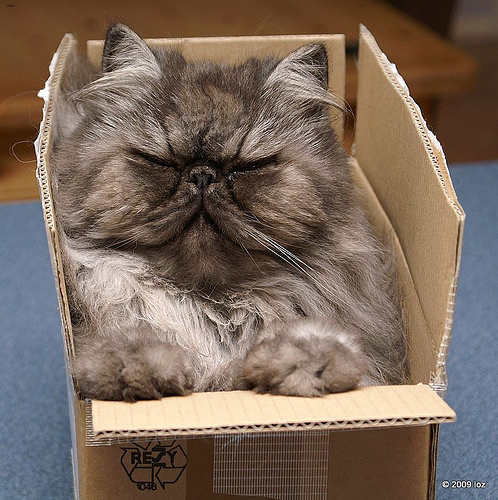


質問: この画像の犬または猫の品種を、次の候補から1つ選んでください。
候補: パグ、サモエド、柴犬、ペルシャ、シャム、スフィンクス
品種名だけを出力してください。

正解応答: ペルシャ

--------------------------------

学習前の生成文: Persian
学習後の生成文: ペルシャ

--------------------------------

学習前に抽出した品種名: 判定不能
学習後に抽出した品種名: ペルシャ




ID: 1



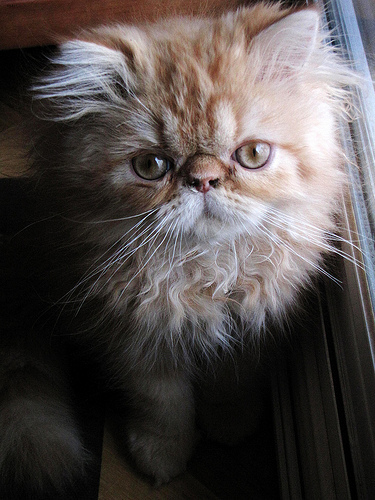


質問: この画像の犬または猫の品種を、次の候補から1つ選んでください。
候補: パグ、サモエド、柴犬、ペルシャ、シャム、スフィンクス
品種名だけを出力してください。

正解応答: ペルシャ

--------------------------------

学習前の生成文: サモエド
学習後の生成文: ペルシャ

--------------------------------

学習前に抽出した品種名: サモエド
学習後に抽出した品種名: ペルシャ




ID: 4



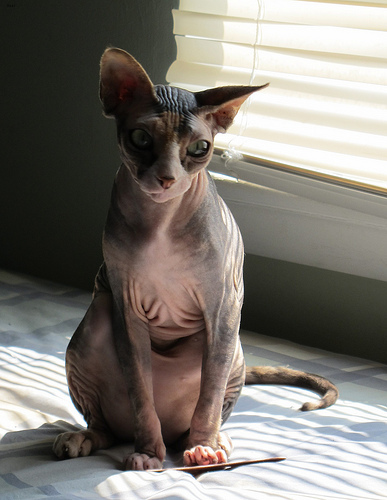


質問: この画像の犬または猫の品種を、次の候補から1つ選んでください。
候補: パグ、サモエド、柴犬、ペルシャ、シャム、スフィンクス
品種名だけを出力してください。

正解応答: スフィンクス

--------------------------------

学習前の生成文: サモエド
学習後の生成文: スフィンクス

--------------------------------

学習前に抽出した品種名: サモエド
学習後に抽出した品種名: スフィンクス




ID: 9



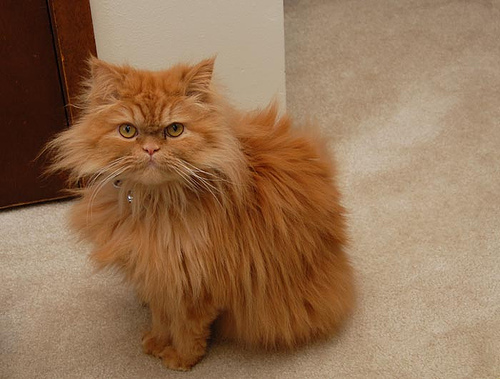


質問: この画像の犬または猫の品種を、次の候補から1つ選んでください。
候補: パグ、サモエド、柴犬、ペルシャ、シャム、スフィンクス
品種名だけを出力してください。

正解応答: ペルシャ

--------------------------------

学習前の生成文: Persian cat
学習後の生成文: ペルシャ

--------------------------------

学習前に抽出した品種名: 判定不能
学習後に抽出した品種名: ペルシャ




ID: 10



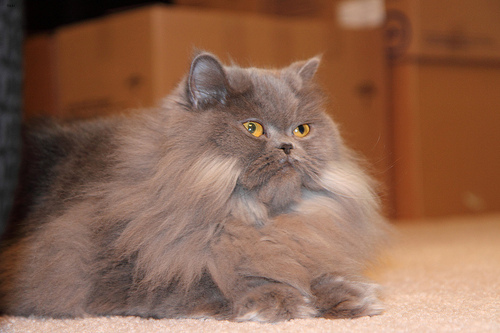


質問: この画像の犬または猫の品種を、次の候補から1つ選んでください。
候補: パグ、サモエド、柴犬、ペルシャ、シャム、スフィンクス
品種名だけを出力してください。

正解応答: ペルシャ

--------------------------------

学習前の生成文: Persian cat
学習後の生成文: ペルシャ

--------------------------------

学習前に抽出した品種名: 判定不能
学習後に抽出した品種名: ペルシャ





In [34]:
# 不正解 → 正解: QLoRA によって品種分類が改善した例
analyzer.display_by_condition(
    "improved",
    max_examples=5,
)

In [35]:
# 正解 → 不正解: 追加学習によって品種分類が悪化した例
analyzer.display_by_condition(
    "degraded",
    max_examples=5,
)

条件: degraded
該当件数: 0
ID: []

条件に一致するサンプルはありません。


条件: format_improved
該当件数: 11
ID: [0, 9, 10, 19, 28, 32, 44, 51, 53, 56, 59]


ID: 0



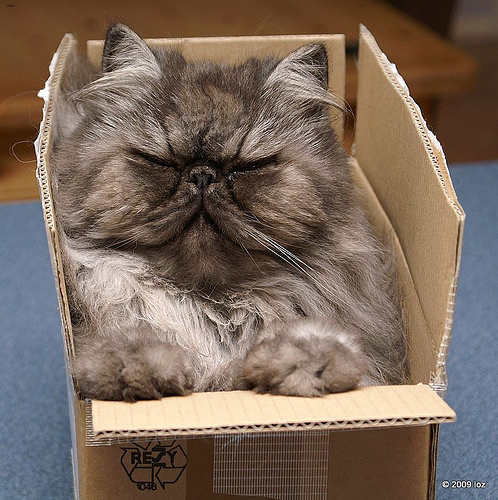


質問: この画像の犬または猫の品種を、次の候補から1つ選んでください。
候補: パグ、サモエド、柴犬、ペルシャ、シャム、スフィンクス
品種名だけを出力してください。

正解応答: ペルシャ

--------------------------------

学習前の生成文: Persian
学習後の生成文: ペルシャ

--------------------------------

学習前に抽出した品種名: 判定不能
学習後に抽出した品種名: ペルシャ




ID: 9



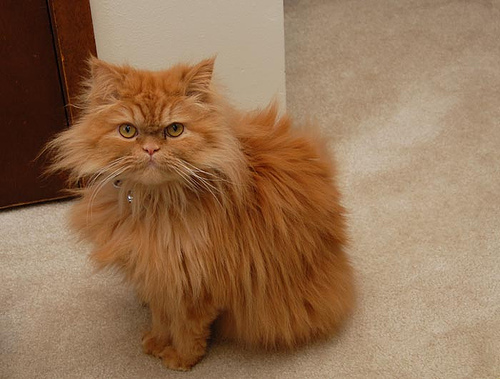


質問: この画像の犬または猫の品種を、次の候補から1つ選んでください。
候補: パグ、サモエド、柴犬、ペルシャ、シャム、スフィンクス
品種名だけを出力してください。

正解応答: ペルシャ

--------------------------------

学習前の生成文: Persian cat
学習後の生成文: ペルシャ

--------------------------------

学習前に抽出した品種名: 判定不能
学習後に抽出した品種名: ペルシャ




ID: 10



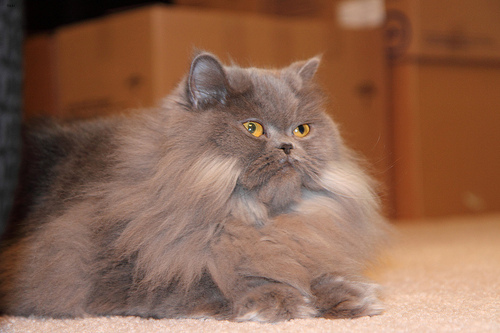


質問: この画像の犬または猫の品種を、次の候補から1つ選んでください。
候補: パグ、サモエド、柴犬、ペルシャ、シャム、スフィンクス
品種名だけを出力してください。

正解応答: ペルシャ

--------------------------------

学習前の生成文: Persian cat
学習後の生成文: ペルシャ

--------------------------------

学習前に抽出した品種名: 判定不能
学習後に抽出した品種名: ペルシャ




ID: 19



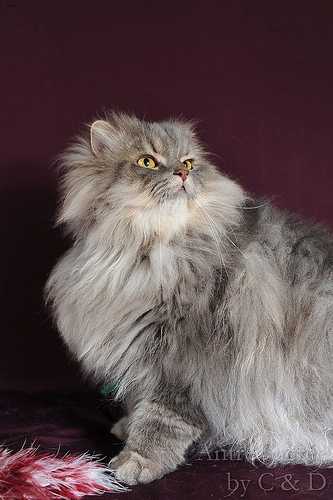


質問: この画像の犬または猫の品種を、次の候補から1つ選んでください。
候補: パグ、サモエド、柴犬、ペルシャ、シャム、スフィンクス
品種名だけを出力してください。

正解応答: ペルシャ

--------------------------------

学習前の生成文: Persian cat
学習後の生成文: ペルシャ

--------------------------------

学習前に抽出した品種名: 判定不能
学習後に抽出した品種名: ペルシャ




ID: 28



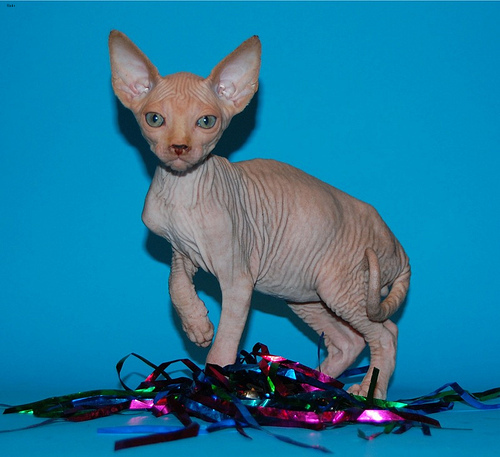


質問: この画像の犬または猫の品種を、次の候補から1つ選んでください。
候補: パグ、サモエド、柴犬、ペルシャ、シャム、スフィンクス
品種名だけを出力してください。

正解応答: スフィンクス

--------------------------------

学習前の生成文: Persian
学習後の生成文: ペルシャ

--------------------------------

学習前に抽出した品種名: 判定不能
学習後に抽出した品種名: ペルシャ





In [36]:
# Format 不正解 → 正解: 「品種名だけを出力する」という出力形式への適応が改善した例
analyzer.display_by_condition(
    "format_improved",
    max_examples=5,
)

### 14. この実装で確認したこと

このノートブックでは、ダウンストリームタスク向けのファインチューニングについて、次の流れを実装しました。

1. 入力画像、ユーザー側の指示文、アシスタント側の正解応答文からなる指示追従形式の学習データを作る。
2. 画像とユーザー側の指示文を主に応答生成の条件として扱い、アシスタント側の正解応答文と、応答終了を表す特殊トークンを主な損失計算対象にする。
3. 視覚エンコーダと LVLM のアダプタを固定し、LLM 側の主要な線形層へ LoRA を入れる。
4. LLM 側の主要な線形層の重みを 4 ビットで保持する QLoRA によって、GPU メモリ使用量を抑えて追加学習する。
5. 学習後に LoRA の差分を元の BF16 モデルへ足し合わせ、通常の BF16 モデルとして保存する。
6. 学習前の BF16 ベースモデルと学習後の BF16 モデルを同じ評価データで比較する。
7. `Accuracy` と `Format Accuracy` に加えて、生成結果そのものを定性分析する。

この例では LLM 側だけを LoRA で調整しましたが、対象タスクで必要な視覚情報が応答にうまく反映されない場合には、視覚エンコーダやLVLM のアダプタも学習対象にすることを検討できます。  